# Báo cáo huấn luyện: Phân loại kiểu dáng xe (Sedan / Gầm cao / Xe tải)

Notebook thu hoạch: đọc lại artifact đã lưu từ `src/ml/train_vehicle_classifier.py`
(checkpoint, epoch-history JSON, resource-usage CSV, run manifest). Notebook này
không train lại, chỉ phân tích và trực quan hóa kết quả đã có.

**Kiến trúc pipeline:**
- **Loại thô** (car/motorcycle/bus/truck): một model YOLO pretrained trên COCO, không
  cần huấn luyện thêm. Trong thử nghiệm này nhóm dùng cụ thể YOLOv8n.
- **Kiểu dáng xe con** (chỉ chạy khi loại thô là `car`): model tự huấn luyện trong
  notebook này, 3 lớp gộp từ 12 kiểu dáng gốc của B5 (Vehicle Body Style Dataset):
  - `Sedan`: Sedan, Fastback, Hatchback, Wagon, Convertible, Hardtop Convertible, Sports
  - `GamCao`: SUV, Crossover, MPV, Minibus
  - `XeTai`: Pickup Truck
- 2 kiến trúc so sánh: ResNet18, MobileNetV3-Small.

## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve().parents[2] if (Path.cwd().name == "notebooks") else Path.cwd()
EXPERIMENTS_DIR = REPO_ROOT / "src" / "ml" / "experiments"
DATA_DIR = REPO_ROOT / "data" / "processed" / "vehicle-style"
FIG_DIR = REPO_ROOT / "docs" / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["resnet18", "mobilenet_v3_small"]
MODEL_LABELS = {"resnet18": "ResNet18", "mobilenet_v3_small": "MobileNetV3-Small"}
# Cặp màu categorical đã validate qua dataviz skill (CVD-safe, xem scripts/validate_palette.js)
MODEL_COLORS = {"resnet18": "#2a78d6", "mobilenet_v3_small": "#eb6834"}
CLASS_LABELS = {"Sedan": "Sedan", "GamCao": "Gầm cao", "XeTai": "Xe tải"}

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10,
})

manifest = json.loads((EXPERIMENTS_DIR / "run_manifest.json").read_text(encoding="utf-8"))
histories = {
    model: json.loads((EXPERIMENTS_DIR / f"style_{model}_history.json").read_text(encoding="utf-8"))
    for model in MODELS
}
print("Đã đọc manifest +", len(histories), "file history.")


Đã đọc manifest + 2 file history.


## 1. Thông số huấn luyện đã dùng

In [2]:
config_df = pd.DataFrame([
    ("Thiết bị", manifest["device"]),
    ("Optimizer", manifest["optimizer"]),
    ("Learning rate", manifest["lr"]),
    ("Batch size", manifest["batch_size"]),
    ("Epochs", manifest["epochs"]),
    ("Loss", manifest["loss"]),
    ("Augmentation", manifest["augmentation"]),
    ("Nguồn dữ liệu", manifest["data_source"]),
    ("Ghi chú", manifest["note"]),
], columns=["Thông số", "Giá trị"]).set_index("Thông số")
display(config_df.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
).set_caption("Cấu hình huấn luyện"))


,Giá trị
Thông số,
Thiết bị,cuda (NVIDIA GeForce RTX 4070)
Optimizer,Adam
Learning rate,0.000100
Batch size,32
Epochs,15
Loss,"CrossEntropyLoss(weight=class_weights), trọng số nghịch tỉ lệ số mẫu mỗi lớp"
Augmentation,"RandomResizedCrop(224, scale=0.8-1.0), RandomHorizontalFlip, RandomRotation(10), ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)"
Nguồn dữ liệu,"B5 (Vehicle Body Style Dataset), gộp 12 kiểu dáng gốc thành 3 lớp"
Ghi chú,"Loại thô (car/motorcycle/bus/truck) dùng một model YOLO pretrained trên COCO (cụ thể YOLOv8n), không huấn luyện thêm; xem src/ml/predict_vehicle.py"


## 2. Dữ liệu được chia thế nào

Đếm trực tiếp từ thư mục `data/processed/vehicle-style/` (không hard-code số).

In [3]:
def count_split(data_dir: Path) -> pd.DataFrame:
    rows = []
    for split in ("train", "valid", "test"):
        split_dir = data_dir / split
        if not split_dir.exists():
            continue
        for cls_dir in sorted(split_dir.iterdir()):
            n = len(list(cls_dir.glob("*.jpg")))
            rows.append({"split": split, "class": cls_dir.name, "n": n})
    return pd.DataFrame(rows)

counts_df = count_split(DATA_DIR)
pivot = counts_df.pivot(index="class", columns="split", values="n").fillna(0).astype(int)
pivot = pivot[["train", "valid", "test"]]
pivot = pivot.rename(index=CLASS_LABELS)
pivot.loc["TỔNG"] = pivot.sum()
display(
    pivot.style.background_gradient(cmap="Blues", subset=pd.IndexSlice[pivot.index[:-1], :])
    .format("{:,}")
    .set_caption(f"Phân bố lớp - tổng {int(counts_df['n'].sum()):,} ảnh")
)


split,train,valid,test
class,,,
Gầm cao,"2,325",670,334
Sedan,"4,102","1,166",569
Xe tải,587,163,84
TỔNG,"7,014","1,999",987


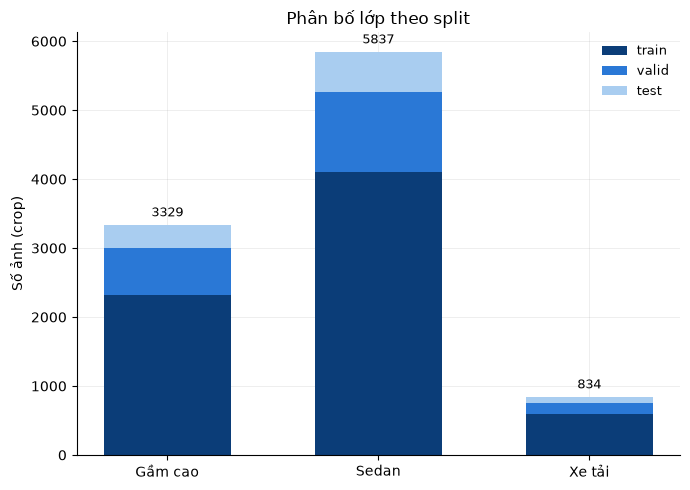

In [4]:
SPLIT_COLORS = {"train": "#0b3d78", "valid": "#2a78d6", "test": "#a9cdf0"}  # 1 hue, sáng->đậm

fig, ax = plt.subplots(figsize=(7, 5))
pv = counts_df.pivot(index="class", columns="split", values="n").fillna(0)[["train", "valid", "test"]]
pv = pv.rename(index=CLASS_LABELS)
bottom = np.zeros(len(pv))
for split in ("train", "valid", "test"):
    ax.bar(pv.index, pv[split], bottom=bottom, label=split, color=SPLIT_COLORS[split], width=0.6)
    bottom += pv[split].values
for i, total in enumerate(bottom):
    ax.text(i, total + max(bottom) * 0.015, f"{int(total)}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Số ảnh (crop)")
ax.set_title("Phân bố lớp theo split")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_style_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Thời gian huấn luyện + tài nguyên sử dụng

Thời gian đọc từ `train_seconds` trong mỗi file history (đo thật bằng `time.perf_counter()` quanh vòng lặp epoch). Tài nguyên CPU/GPU/RAM đọc từ `train_resource_usage.csv` (lấy mẫu mỗi 5 giây trong suốt 2 lượt train, `src/ml/monitor_resources.py`).

In [5]:
duration_rows = []
for model, h in histories.items():
    duration_rows.append({
        "Model": MODEL_LABELS[model],
        "Thời gian (phút)": round(h["train_seconds"] / 60, 2),
        "Số epoch": len(h["epochs"]),
        "Bắt đầu": h["started_at"][:19].replace("T", " "),
        "Kết thúc": h["finished_at"][:19].replace("T", " "),
    })
duration_df = pd.DataFrame(duration_rows)
total_minutes = duration_df["Thời gian (phút)"].sum()
display(
    duration_df.style.background_gradient(cmap="Oranges", subset=["Thời gian (phút)"])
    .format({"Thời gian (phút)": "{:.2f}"})
    .hide(axis="index")
    .set_caption(f"Thời gian train từng lượt - tổng {total_minutes:.1f} phút")
)


Model,Thời gian (phút),Số epoch,Bắt đầu,Kết thúc
ResNet18,6.09,15,2026-08-07 16:13:55,2026-08-07 16:20:01
MobileNetV3-Small,6.09,15,2026-08-07 16:20:03,2026-08-07 16:26:09


In [6]:
res_path = REPO_ROOT / "train_resource_usage.csv"
res_df = pd.read_csv(res_path, parse_dates=["timestamp"])
stats = res_df[["cpu_pct", "ram_used_gb", "gpu_util_pct", "gpu_mem_used_mb"]].agg(["mean", "max"]).T
stats.columns = ["Trung bình", "Đỉnh"]
stats.index = ["CPU (%)", "RAM (GB)", "GPU (%)", "VRAM (MB)"]
display(
    stats.style.format("{:.1f}").background_gradient(cmap="Reds", axis=1)
    .set_caption(f"Tài nguyên hệ thống - {len(res_df)} mẫu, lấy mỗi 5 giây")
)


,Trung bình,Đỉnh
CPU (%),11.5,31.3
RAM (GB),31.2,31.9
GPU (%),25.6,98.0
VRAM (MB),3515.8,3616.0


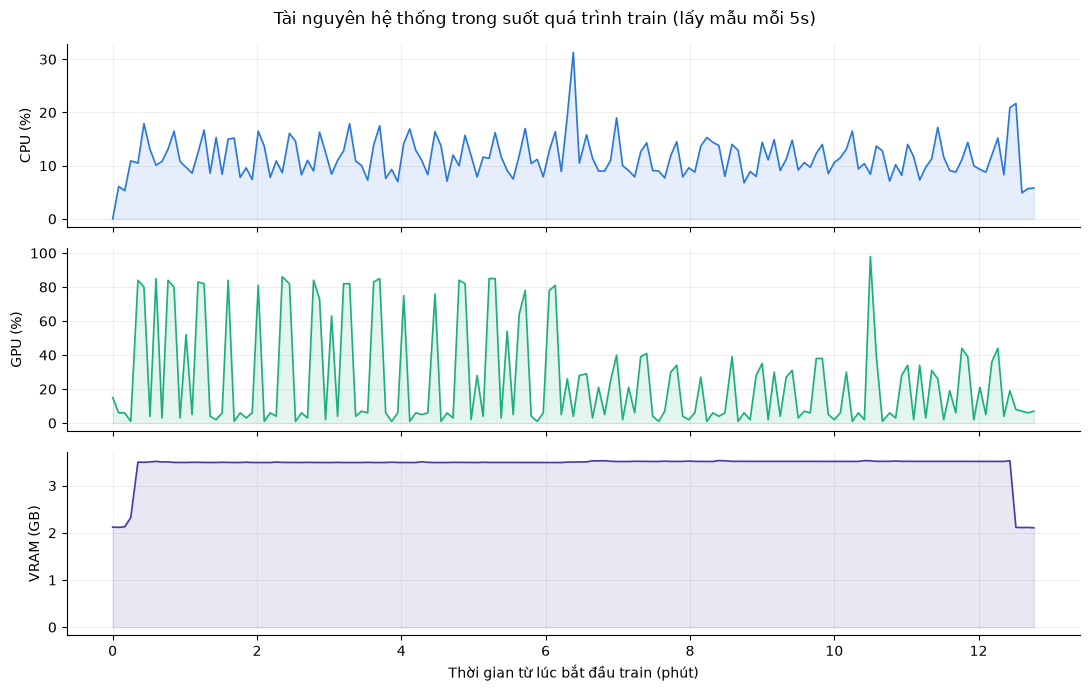

In [7]:
RES_COLORS = {"cpu": "#2a78d6", "gpu": "#1baf7a", "vram": "#4a3aa7"}
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
t = (res_df["timestamp"] - res_df["timestamp"].iloc[0]).dt.total_seconds() / 60
for ax, col, label, color in zip(
    axes, ["cpu_pct", "gpu_util_pct", "gpu_mem_used_mb"],
    ["CPU (%)", "GPU (%)", "VRAM (GB)"], [RES_COLORS["cpu"], RES_COLORS["gpu"], RES_COLORS["vram"]],
):
    y = res_df[col] / 1024 if col == "gpu_mem_used_mb" else res_df[col]
    ax.plot(t, y, color=color, linewidth=1.2)
    ax.fill_between(t, y, alpha=0.12, color=color)
    ax.set_ylabel(label)
axes[-1].set_xlabel("Thời gian từ lúc bắt đầu train (phút)")
fig.suptitle("Tài nguyên hệ thống trong suốt quá trình train (lấy mẫu mỗi 5s)")
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_style_resource_usage.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Phân tích quá trình train: đường loss/accuracy theo epoch

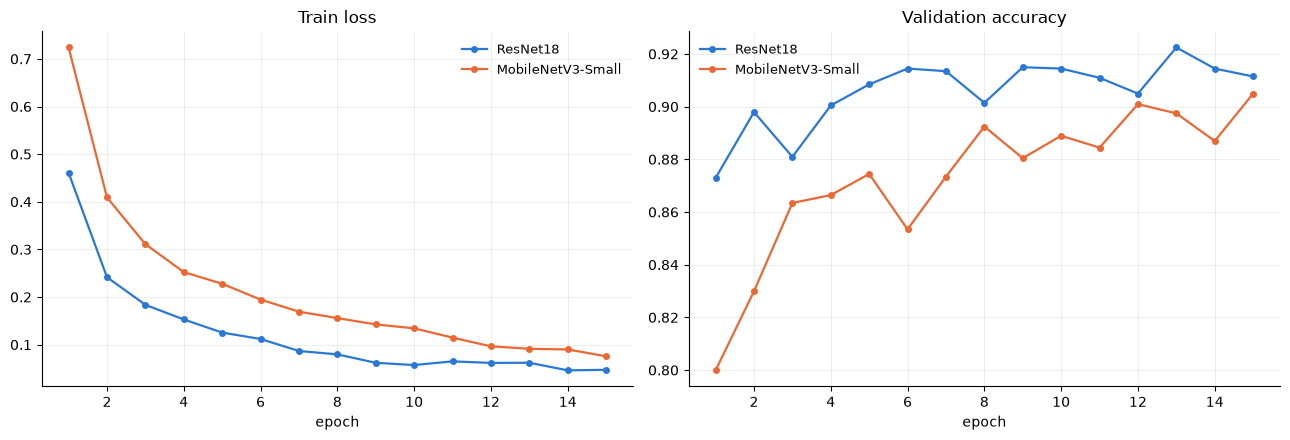

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for model in MODELS:
    h = histories[model]
    epochs = [e["epoch"] for e in h["epochs"]]
    train_loss = [e["train_loss"] for e in h["epochs"]]
    val_acc = [e["val_acc"] for e in h["epochs"]]
    c = MODEL_COLORS[model]
    axes[0].plot(epochs, train_loss, marker="o", label=MODEL_LABELS[model], markersize=4, color=c, linewidth=1.6)
    axes[1].plot(epochs, val_acc, marker="o", label=MODEL_LABELS[model], markersize=4, color=c, linewidth=1.6)
axes[0].set_title("Train loss"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=9, frameon=False)
axes[1].set_title("Validation accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_style_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()


**Nhận xét:** cả 2 kiến trúc hội tụ nhanh và ổn định, accuracy epoch 1 đã đạt 0,80 đến 0,87. ResNet18 hội tụ nhanh và ổn định hơn MobileNetV3-Small trong vài epoch đầu, nhưng đến epoch 10-15 khoảng cách giữa 2 kiến trúc thu hẹp đáng kể.

## 5. Kết quả cuối trên tập test: so sánh 2 kiến trúc

In [9]:
summary_rows = []
for model, h in histories.items():
    t = h["test"]
    summary_rows.append({
        "Model": MODEL_LABELS[model],
        "Accuracy": round(t["accuracy"], 4), "F1-macro": round(t["f1_macro"], 4),
        "Params": h["params"], "ONNX (MB)": h["onnx_size_mb"], "CPU (ms)": round(h["cpu_ms"], 2),
    })
summary_df = pd.DataFrame(summary_rows)

def style_best(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    for col in ("Accuracy", "F1-macro"):
        best_idx = data[col].idxmax()
        styles.loc[best_idx, col] = "background-color: #d7ecc8; font-weight: bold"
    return styles

display(
    summary_df.style
    .apply(style_best, axis=None)
    .format({"Accuracy": "{:.2%}", "F1-macro": "{:.2%}", "Params": "{:,}", "ONNX (MB)": "{:.2f}", "CPU (ms)": "{:.2f}"})
    .hide(axis="index")
    .set_caption("Kết quả trên tập test - màu xanh lá cây = tốt nhất")
)


Model,Accuracy,F1-macro,Params,ONNX (MB),CPU (ms)
ResNet18,89.97%,90.12%,"11,178,051",44.70,8.57
MobileNetV3-Small,90.07%,90.69%,"1,520,931",6.09,4.82


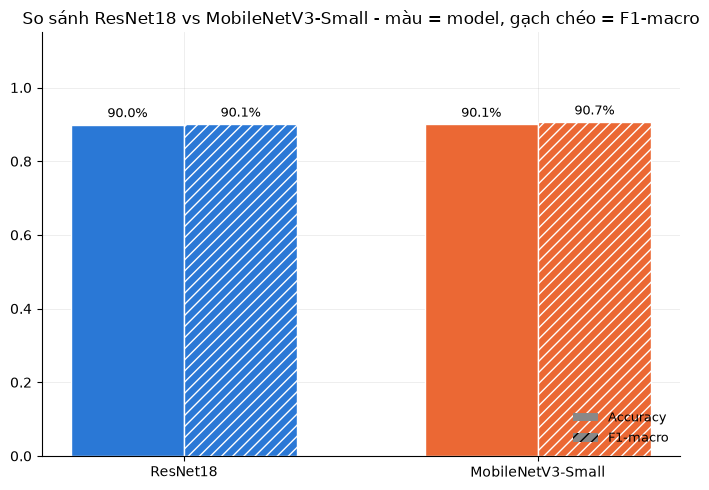

In [10]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(7, 5))
width = 0.32
for i, model in enumerate(MODELS):
    r = summary_df[summary_df["Model"] == MODEL_LABELS[model]].iloc[0]
    c = MODEL_COLORS[model]
    ax.bar(i - width / 2, r["Accuracy"], width, color=c, edgecolor="white")
    ax.bar(i + width / 2, r["F1-macro"], width, color=c, hatch="///", edgecolor="white")
    ax.text(i - width / 2, r["Accuracy"] + 0.02, f"{r['Accuracy']:.1%}", ha="center", fontsize=9)
    ax.text(i + width / 2, r["F1-macro"] + 0.02, f"{r['F1-macro']:.1%}", ha="center", fontsize=9)
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS])
ax.set_ylim(0, 1.15)
legend_elems = [Patch(facecolor="#888", label="Accuracy"), Patch(facecolor="#888", hatch="///", label="F1-macro")]
ax.legend(handles=legend_elems, fontsize=9, frameon=False, loc="lower right")
ax.set_title("So sánh ResNet18 vs MobileNetV3-Small - màu = model, gạch chéo = F1-macro")
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_style_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Ma trận nhầm lẫn từng kiến trúc

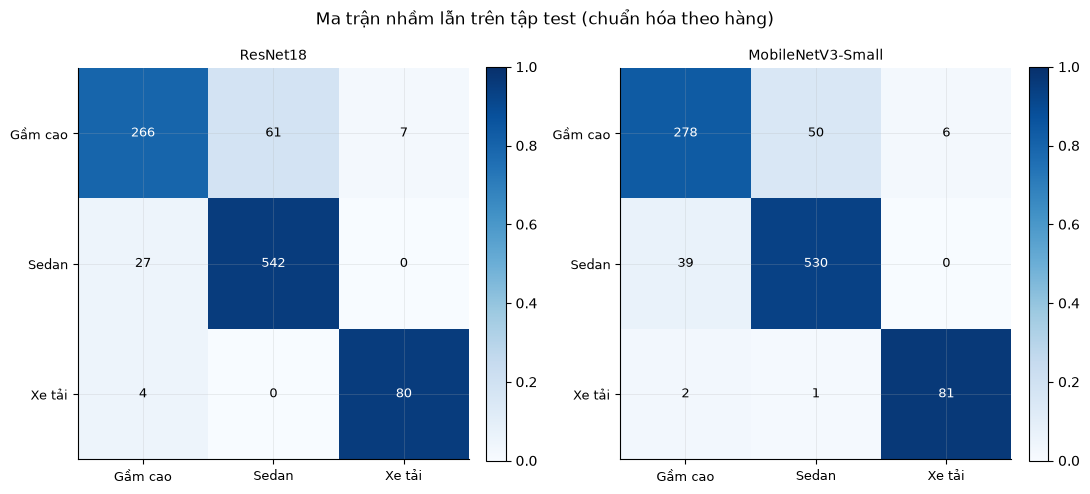

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, model in zip(axes, MODELS):
    h = histories[model]
    cm = np.array(h["test"]["confusion_matrix"])
    classes = h["class_names"]
    classes_display = [CLASS_LABELS.get(c, c) for c in classes]
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes_display, fontsize=9)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes_display, fontsize=9)
    ax.set_title(MODEL_LABELS[model], fontsize=10)
    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm[i, j]
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(val), ha="center", va="center", fontsize=9, color=color)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Ma trận nhầm lẫn trên tập test (chuẩn hóa theo hàng)")
fig.tight_layout()
fig.savefig(FIG_DIR / "vehicle_style_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Tổng kết

- Gộp 12 kiểu dáng gốc (B5) thành 3 nhóm thực dụng hơn (`Sedan`, `GamCao`, `XeTai`): ResNet18 đạt accuracy 0,900 (F1-macro 0,901), MobileNetV3-Small đạt accuracy 0,901 (F1-macro 0,907). Với chỉ 3 lớp, MobileNetV3-Small gần như bắt kịp ResNet18 về độ chính xác.
- Về chi phí tính toán: ResNet18 nặng hơn MobileNetV3-Small khoảng 7,3 lần (tham số, dung lượng ONNX). Với accuracy gần tương đương, MobileNetV3-Small là lựa chọn hợp lý hơn cho mục tiêu triển khai Edge (Raspberry Pi 5); quyết định chính thức để dành Tuần 7-8, dựa trên số đo thật trên Pi 5.
- Loại thô (car/motorcycle/bus/truck) dùng một model YOLO pretrained trên COCO, không cần huấn luyện thêm; trong notebook này cụ thể là YOLOv8n. Bảng test ảnh thật ở `docs/report/chapters/05-phanloai.md` mục 5.5 có chi tiết kết quả.